Script: Practice with package: Pyicon
- Author: Muxin Hu (muxin.hu@mpimet.mpg.de)
- Date created: 04/11/2025
- Late modified: 04/11/2025 

the package is downloaded and installed in the directory: /home/m/m301254/Download/pyicon


In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dask.array as da
import xarray as xr
import pyicon as pyic
import cartopy.crs as ccrs
import cmocean
%matplotlib inline

import cartopy.feature as cfeature
from matplotlib import cm

from scipy.interpolate import CloughTocher2DInterpolator, LinearNDInterpolator, NearestNDInterpolator

----Start loading pyicon.
Loading default parameters from /home/m/m301254/Download/pyicon/pyicon/params_default.json.
----Start loading pyicon.
----Pyicon was loaded successfully.
----Pyicon was loaded successfully.


# Analysis on ICON-o test run
- for the ICON-o documentation, please go: https://icon-o.gitlab-pages.dkrz.de/icon-o-documentation/
- for the script running the icon-o, please find the section: Quickstart Tutorial + Running ICON-O
    - The current script reference can be visualised in: /work/mh0033/m301254/proj_surfwave/icon_2025_04_2_public/icon-model/prepare.sh
- The test runs for 10 years, with the results stored in: /work/mh0033/m301254/proj_surfwave/icon_2025_04_2_public/icon-model/experiments/test20251029/
- The test runs with the grid resolution as: icon_grid_0036_R02B04_O.nc

# Use pyic package to load the ICON Dataset

In [2]:
# import necessary libraries
from netCDF4 import Dataset
import sys

In [ ]:
# Names and paths
run='test20251029'
gname='r2b4_oce_r0004'
lev='L40'

path_data = f'/work/mh0033/m301254/proj_surfwave/icon-2025-04_2-public/icon-model/experiments/{run}/'
path_grid = f'/home/m/m301254/pyicon_data/grids/{gname}/'
path_ckdtree= f'{path_grid}ckdtree/'                             # useful for large data interpolation
fpath_fx = f'{path_grid}{gname}_{lev}_fx.nc'

## Pyicon IconData Object
- create a pyicon IconData object. 
- IcD **doesn't load all the data into memeory**, but instead stores paths, times, and grid infor in sturctured way

In [ ]:
# Pyicon IconData obeject
IcD = pyic.IconData(
            fname              = run+'_P1M_3d_*.nc',   # place holder, match the lenth of the file names
            path_data          = path_data,
            path_grid          = path_grid,
            gname              = gname,
            lev                = lev,
            path_ckdtree       = path_ckdtree,
            fpath_fx           = fpath_fx,
            do_triangulation   = True,
            omit_last_file     = False
)

# Note that we can also crop the region domain by adding: lon_reg and lat_reg in real lims in lat and lon

Start with calc_coeff...
Done with calc_coeff!


### A list of all attributes in IconData

In [5]:
attrs = [a for a in dir(IcD) if not a.startswith('_')]
for a in attrs:
    try:
        val = getattr(IcD, a)
        print(f"{a} : {type(val)} {getattr(val, 'shape', '')}")
    except Exception as e:
        print(f"{a} : <couldn’t retrieve> {e}")

Lat : <class 'numpy.ndarray'> (600, 1200)
Lon : <class 'numpy.ndarray'> (600, 1200)
Tri : <class 'matplotlib.tri._triangulation.Triangulation'> 
adjacent_cell_of_edge : <class 'numpy.ma.MaskedArray'> (23207, 2)
alf : <class 'float'> 
associate_variables : <class 'method'> 
calc_coeff : <class 'method'> 
calc_coeff_mappings : <class 'method'> 
cell_area : <class 'numpy.ma.MaskedArray'> (15105,)
cell_area_p : <class 'numpy.ma.MaskedArray'> (15105,)
cell_cart_vec : <class 'numpy.ma.MaskedArray'> (15105, 3)
cell_sea_land_mask : <class 'numpy.ma.MaskedArray'> (15105,)
cells_of_vertex : <class 'numpy.ma.MaskedArray'> (8067, 6)
clat : <class 'numpy.ma.MaskedArray'> (15105,)
clon : <class 'numpy.ma.MaskedArray'> (15105,)
constantPrismCenters_Zdistance : <class 'numpy.ma.MaskedArray'> (41, 15105)
cp : <class 'float'> 
crop_data : <class 'bool'> 
crop_rgrid : <class 'method'> 
crop_tgrid : <class 'method'> 
data : <class 'dict'> 
depthc : <class 'numpy.ma.MaskedArray'> (40,)
depthi : <class 'num

In [6]:
# check the IconData object: times and depthc
print(type(IcD.times))
print(IcD.times)                      # a list of datetime objects, covering from the first to the last files with '_P1M_3d_*.nc'
print(len(IcD.times))
# print(type(IcD.depthc), IcD.depthc)
print(len(IcD.flist_ts))
print(IcD.its[:])                     # a list of time indices corresponding to IcD.times, a loop from 0 to 12, looping through all files


<class 'numpy.ma.MaskedArray'>
['2000-01-01T00:00:00' '2000-02-01T00:00:00' '2000-03-01T00:00:00'
 '2000-04-01T00:00:00' '2000-05-01T00:00:00' '2000-06-01T00:00:00'
 '2000-07-01T00:00:00' '2000-08-01T00:00:00' '2000-09-01T00:00:00'
 '2000-10-01T00:00:00' '2000-11-01T00:00:00' '2000-12-01T00:00:00'
 '2001-01-01T00:00:00' '2001-02-01T00:00:00' '2001-03-01T00:00:00'
 '2001-04-01T00:00:00' '2001-05-01T00:00:00' '2001-06-01T00:00:00'
 '2001-07-01T00:00:00' '2001-08-01T00:00:00' '2001-09-01T00:00:00'
 '2001-10-01T00:00:00' '2001-11-01T00:00:00' '2001-12-01T00:00:00'
 '2002-01-01T00:00:00' '2002-02-01T00:00:00' '2002-03-01T00:00:00'
 '2002-04-01T00:00:00' '2002-05-01T00:00:00' '2002-06-01T00:00:00'
 '2002-07-01T00:00:00' '2002-08-01T00:00:00' '2002-09-01T00:00:00'
 '2002-10-01T00:00:00' '2002-11-01T00:00:00' '2002-12-01T00:00:00'
 '2003-01-01T00:00:00' '2003-02-01T00:00:00' '2003-03-01T00:00:00'
 '2003-04-01T00:00:00' '2003-05-01T00:00:00' '2003-06-01T00:00:00'
 '2003-07-01T00:00:00' '2003-08

### Load the data

In [7]:
# specify time and depth index
it = np.argmin(np.abs(IcD.times-np.datetime64('2009-01-01T00:00:00'))) # find the index of time closest to 2009-01-01T00:00:00
# it2 = np.argmin(np.abs(IcD.times-np.datetime64('2007-02-01T00:00:00'))) 
iz = np.argmin(np.abs(IcD.depthc - 0.0))                             # find the index of depth closest to 100.0, use np.argmin
print(f'time step that is closest to the desried time, starting from the first file in IcD: {it}')
# print(it2)
print(f'level steo that is closest to the desrired level: {iz}')

time step that is closest to the desried time, starting from the first file in IcD: 108
level steo that is closest to the desrired level: 0


In [8]:
print(IcD.flist_ts[it])
# print(IcD.flist_ts[it2])

/work/mh0033/m301254/proj_surfwave/icon_2025_04_2_public/icon-model/experiments/test20251029/test20251029_P1M_3d_20090101T000000Z.nc


- **IcD.flist_ts[it]**: get the full filename for the file that contains the it-th time step
- **IcD.its[it]**: get the time step inside that file to read; sicne IcD.its[:] is a loop from 0-11 for each single file

In [9]:
# open the file that contains the specified time
f = Dataset(IcD.flist_ts[it], 'r')               
 
# specify the exact one time step and depth for the to field
to = f.variables['to'][IcD.its[it],iz,:]         # IcD.its[it]: single time step
to_3d = f.variables['to'][IcD.its[it],:,:]       # all depth levels 
# f.close()

- Even though the time is specified, the f still contains 12 timesteps. 
    - This is because the file is /{run}_P1M_3d_20090101T000000Z.nc, only specify one time, **but contains all 12 timesteps of that year**
- However, the *to* and *to_3d* are only for single timestep, since they are indicated by ICD.its[it], which specify the exact timestep in the corresponding files

In [10]:
# check the data:
print(f.variables.keys())
print('----------------')
print(f['time'])             # 12 time stpes in one dataset (IcD.flist_ts[it])
print('----------------')
print(f['depth'])            # 40 depth levels
print('----------------')
print(to.shape)              # the to field at one time and one depth level
print(to_3d.shape)           # the to field at one time and all depth levels

dict_keys(['time', 'clon', 'clon_bnds', 'clat', 'clat_bnds', 'elon', 'elon_bnds', 'elat', 'elat_bnds', 'depth', 'depth_2', 'to', 'so', 'u', 'v', 'w', 'A_veloc_v', 'A_tracer_v_to', 'A_tracer_v_so', 'normal_velocity', 'rho', 'rhopot', 'mass_flux', 'heat_content_liquid_water', 'swrab', 'rsdoabsorb', 'tke'])
----------------
<class 'netCDF4.Variable'>
float64 time(time)
    standard_name: time
    calendar: gregorian
    axis: T
    units: minutes since 2000-1-1 00:00:00
unlimited dimensions: time
current shape = (12,)
filling off
----------------
<class 'netCDF4.Variable'>
float64 depth(depth)
    standard_name: depth
    long_name: depth_below_sea
    units: m
    positive: down
    axis: Z
unlimited dimensions: 
current shape = (40,)
filling off
----------------
(15105,)
(40, 15105)


## Plotting on the original triangular grid
First mask land values (simply assuming that 0 data values are land):

In [11]:
mask_land = to.mask    # get the mask from the icon dataset
# The mask need to be applied to IconData triangulation object
# It is important to add the mask to the IcD.mask_bt mask which masks longitudinally periodic traiangles
IcD.Tri.set_mask(IcD.mask_bt+mask_land)

**pyic.arrange_axes()** 
- is a helper function in pyicon_plotting.py that makes it easy to create one or several subplots with consistent layout, aspect ratio, and colorbar positioning.
- function signatures:
    - hca: list of axes
    - hcb: list of colorbar axes
    - plot_cb: creast a color bar axis beside each subplot
    - asp: aspect ratio of the subplots
    - sasp: secondary aspect ratio adjustment (rarelt use)
    - fig_size_fac: scaling factor for overal figure size
    - xlable, ylabel: text laberls for x and y axes
    - do_axes_labels: if False, suppresses al axis labels
    - fs_lable, fs_title, fs_ticks: font sizes controller
    - dfigl, dfigr, dfigt, dfigb: margins between figure and axes
    - daxl, daxr, daxt, daxb: Spacing around axes (inner margins)
    - wax, hax: Width and height of axes (can be 'auto')
    - .... see detailed descriptions

Text(0.5, 1.0, '$^o$C')

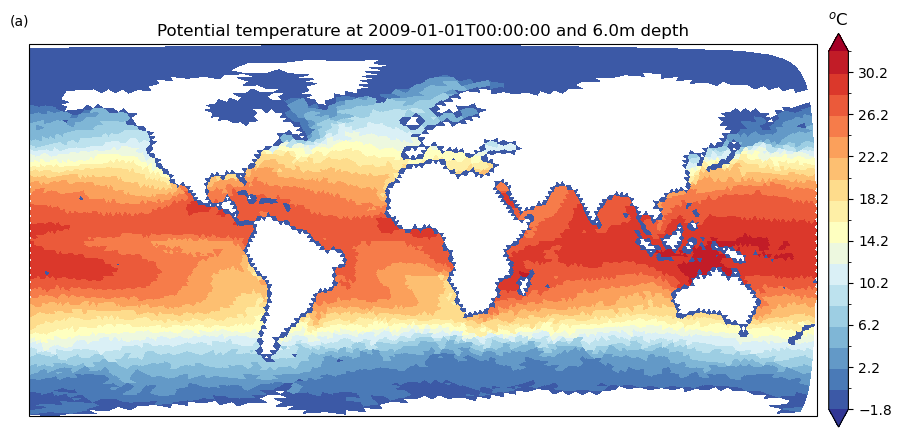

In [12]:
hca, hcb = pyic.arrange_axes(1,1, plot_cb=True, asp=0.5, fig_size_fac=2.5, projection=ccrs.Miller())
ii=-1   # give an index for the axis: useful way to keep track of subplot indices, especially when dealing with multiple subplots

ii+=1; ax=hca[ii]; cax=hcb[ii]
pyic.shade(IcD.Tri, to, ax=ax, cax=cax, clim='auto', cincr=2)   # clim: color limits; cincr: color increment
# ax.set_extent([-140,-40,-40,40], crs=ccrs.Miller())             # notice: shoud use the same projection as the axis
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Potential temperature at %s and %.1fm depth'%(IcD.times[it], IcD.depthc[iz]))
cax.set_title('$^o$C')

Text(0.5, 1.0, '$^o$C')

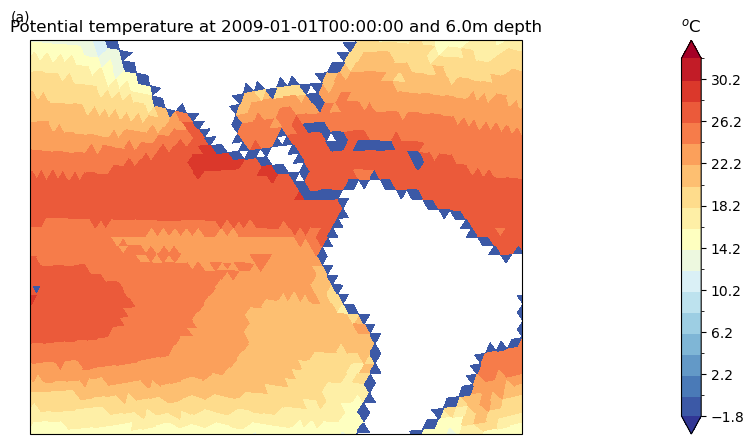

In [13]:
# can also use a regular way to plot
hca, hcb = pyic.arrange_axes(1,1, plot_cb=True, asp=0.5, fig_size_fac=2.5, projection=ccrs.Miller())
ax = hca[0]  # get the first (and only) axis
cax = hcb[0] # get the first (and only) colorbar axis

pyic.shade(IcD.Tri, to, ax=ax, cax=cax, clim='auto', cincr=2)   # clim: color limits; cincr: color increment
ax.set_extent([-140,-40,-40,40], crs=ccrs.Miller())             # notice: use the same projection as the axis
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Potential temperature at %s and %.1fm depth'%(IcD.times[it], IcD.depthc[iz]))
cax.set_title('$^o$C')

## Interpolate data to a regular grid
Use the pyicon interp_to_rectgrid function. 
- The path to the regular grid ckdtree file (fpath_ckdtree) needs to be specified. 
- It decides which regular grid is taken but only those grids can be chosen which were calculated and saved externally.



In [14]:
print(path_ckdtree)                        # useful for large data interpolation

/home/m/m301254/pyicon_data/grids/r2b4_oce_r0004/ckdtree/


In [15]:
fpath_ckdtree = f'{path_ckdtree}rectgrids/r2b4_oce_r0004_res0.30_180W-180E_90S-90N.npz'   # resolution 1.0 degree for r2b4_oce_r004
# apply interpolation to rectgrid
lon, lat, toi = pyic.interp_to_rectgrid(
    to, 
    fpath_ckdtree, 
    coordinates='clat clon'
)        # lon, lat: interpolated lon and lat; toi: interpolated to field

Text(0.5, 1.0, '$^o$C')

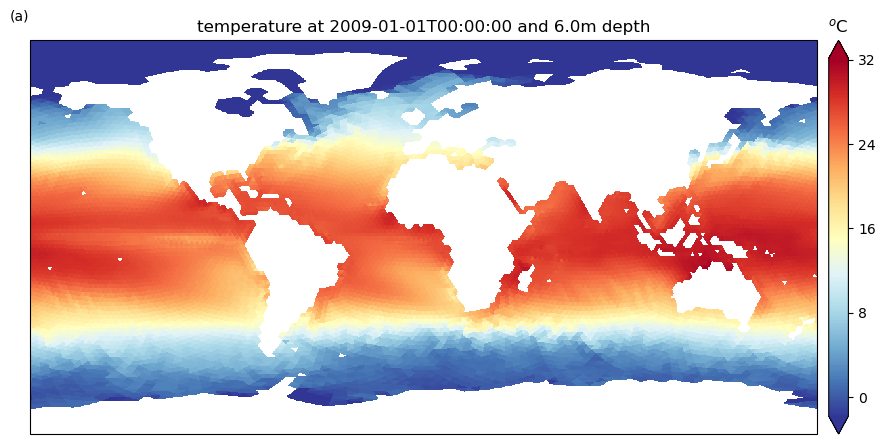

In [16]:
hca, hcb = pyic.arrange_axes(1,1, plot_cb=True, asp=0.5, fig_size_fac=2.5, projection=ccrs.Miller())
ii=-1

ii+=1; ax=hca[ii]; cax=hcb[ii]
pyic.shade(lon, lat, toi, ax=ax, cax=cax, clim='auto')          # still use pyic.shade
# ax.set_extent([-140,-40,-40,40], crs=ccrs.Miller())             # notice: shoud use the same projection as the axis
ax.set_xlabel('longitude')
ax.set_ylabel('latitude')
ax.set_title('temperature at %s and %.1fm depth'%(IcD.times[it], IcD.depthc[iz]))
cax.set_title('$^o$C')


## Interpolate data to a section
Use the pyicon interp_to_section function: 
- The path to the section ckdtree file (fpath_ckdtree_sec) needs to be specified. 
    - It decides which section file is taken but only those sections can be chosen which were calculated and saved externally.

### For the potential Temperature

In [17]:
fpath_ckdtree_sec = f'{path_ckdtree}sections/{gname}_nps200_30W80S_30W80N.npz'   # section from 30W80S to 30W80N (Atlantic)
# print(fpath_ckdtree_sec)
# apply the interpolation to section
lon_sec, lat_sec, depth_sec, to_sec = pyic.interp_to_section(
    to_3d,
    fpath_ckdtree_sec,
    coordinates='clat clon',
    # depth=IcD.depthc
)

In [18]:
print(np.max(IcD.depthc))
print(IcD.depthc[0])

5720.0
6.0


(5720.0, 0.0)

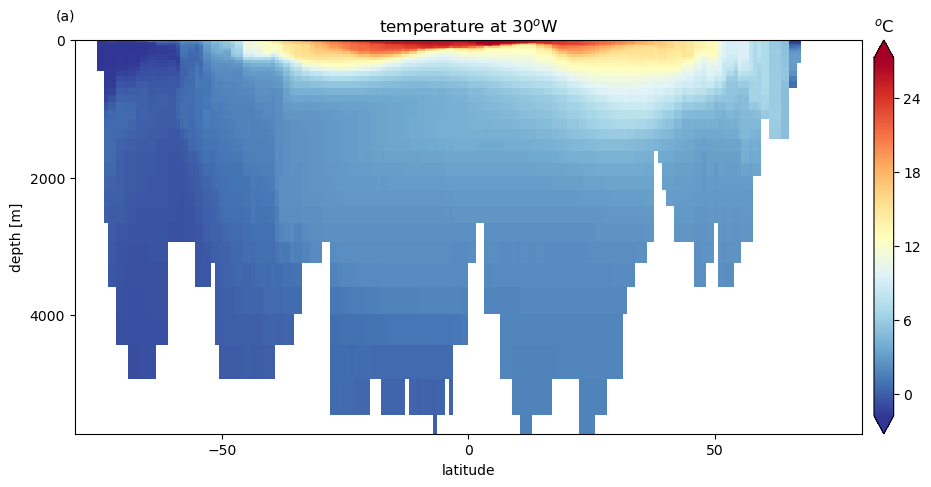

In [19]:
hca, hcb = pyic.arrange_axes(1,1, plot_cb=True, asp=0.5, fig_size_fac=2.5,
                             xlabel='latitude', ylabel='depth [m]')
ii=-1

ii+=1; ax=hca[ii]; cax=hcb[ii]
pyic.shade(lat_sec, IcD.depthc, to_sec, ax=ax, cax=cax, clim='auto')
ax.set_title('temperature at 30$^o$W')
cax.set_title('$^o$C')
ax.set_ylim(IcD.depthc[-1],0)   # depth: positive, need to reverse the y axis
# ax.set_xlim(0, 75)

### For the TKE

In [20]:
ds02 = xr.open_dataset(IcD.flist_ts[it])
ds02

<xarray.Dataset> Size: 518MB
Dimensions:                    (ncells: 15105, vertices: 3, ncells_2: 23207,
                                vertices_2: 4, time: 12, depth: 40, depth_2: 41)
Coordinates:
  * time                       (time) datetime64[ns] 96B 2009-01-01 ... 2009-...
  * depth                      (depth) float64 320B 6.0 17.0 ... 5.72e+03
  * depth_2                    (depth_2) float64 328B 0.0 12.0 ... 6.02e+03
    clon                       (ncells) float64 121kB ...
    clat                       (ncells) float64 121kB ...
    elon                       (ncells_2) float64 186kB ...
    elat                       (ncells_2) float64 186kB ...
Dimensions without coordinates: ncells, vertices, ncells_2, vertices_2
Data variables: (12/20)
    clon_bnds                  (ncells, vertices) float64 363kB ...
    clat_bnds                  (ncells, vertices) float64 363kB ...
    elon_bnds                  (ncells_2, vertices_2) float64 743kB ...
    elat_bnds                  (ncells_2, vertices_2) float64 743kB ...
    to                         (time, depth, ncells) float32 29MB ...
    so                         (time, depth, ncells) float32 29MB ...
    ...                         ...
    rhopot                     (time, depth, ncells) float32 29MB ...
    mass_flux                  (time, depth, ncells_2) float32 45MB ...
    heat_content_liquid_water  (time, depth, ncells) float32 29MB ...
    swrab                      (time, depth, ncells) float32 29MB ...
    rsdoabsorb                 (time, depth, ncells) float32 29MB ...
    tke                        (time, depth_2, ncells) float32 30MB ...
Attributes:
    CDI:                  Climate Data Interface version 2.5.2 (https://mpime...
    Conventions:          CF-1.6
    number_of_grid_used:  36
    grid_file_uri:        http://icon-downloads.mpimet.mpg.de/grids/public/mp...
    uuidOfHGrid:          5bd948e8-ac1a-11ea-a6b1-d317264fdca9
    institution:          Max Planck Institute for Meteorology/Deutscher Wett...
    title:                ICON simulation
    source:               version: 2025.04-2; revision: icon-2025.04-2-public...
    history:              /work/mh0033/m301254/icon-model/bin/icon at 2025102...
    references:           see MPIM/DWD publications
    comment:              Muxin Hu (m301254) on l30472 (Linux 4.18.0-553.74.1...

In [21]:
# recal the Dataset "f", specifiy the timestep of IcD.its[it]
tke_3d = f.variables['tke'][IcD.its[it],:,:]

In [22]:
# apply the interpolation to section
lon_sec, lat_sec, depth_sec, tke_sec = pyic.interp_to_section(
    tke_3d,
    fpath_ckdtree_sec,
    coordinates='clat clon',
    # depth=IcD.depthc
)

#### Be careful the depth coordinate!
- The tke(time, depth_2, ncells) use the 'depth below sea'
- check the attribute for the IconData, we find the 'depth below sea' can be read by **IcD.depthi**

In [23]:
vars(IcD)

{'verbose': False,
 'path_data': '/work/mh0033/m301254/proj_surfwave/icon_2025_04_2_public/icon-model/experiments/test20251029/',
 'path_grid': '/home/m/m301254/pyicon_data/grids/r2b4_oce_r0004/',
 'gname': 'r2b4_oce_r0004',
 'lev': 'L40',
 'dtype': 'float32',
 'fpath_tgrid': '/home/m/m301254/pyicon_data/grids/r2b4_oce_r0004/r2b4_oce_r0004_tgrid.nc',
 'fpath_fx': '/home/m/m301254/pyicon_data/grids/r2b4_oce_r0004/r2b4_oce_r0004_L40_fx.nc',
 'path_ckdtree': '/home/m/m301254/pyicon_data/grids/r2b4_oce_r0004/ckdtree/',
 'path_rgrid': '/home/m/m301254/pyicon_data/grids/r2b4_oce_r0004/ckdtree/rectgrids/',
 'path_sections': '/home/m/m301254/pyicon_data/grids/r2b4_oce_r0004/ckdtree/sections/',
 'run': 'test20251029',
 'interpolate': True,
 'units': {},
 'long_name': {},
 'data': {},
 'lon_reg': [-180, 180],
 'lat_reg': [-90, 90],
 'crop_data': False,
 'use_tgrid': False,
 'fname': 'test20251029_P1M_3d_*.nc',
 'model_type': 'oce',
 'iw': None,
 'grid_sphere_radius': 6371229.0,
 'grav': 9.80665,

(0.0, 80.0)

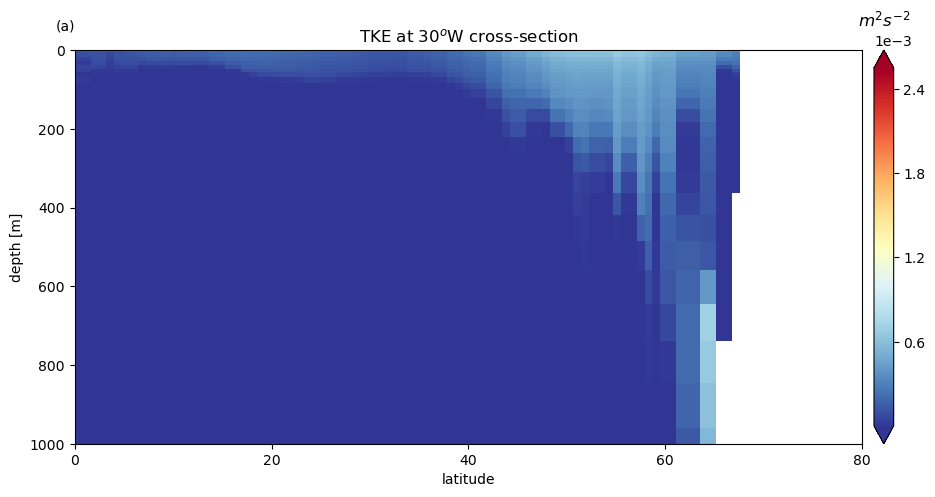

In [24]:
hca, hcb = pyic.arrange_axes(1,1, plot_cb=True, asp=0.5, fig_size_fac=2.5,
                             xlabel='latitude', ylabel='depth [m]')
ii=-1

ii+=1; ax=hca[ii]; cax=hcb[ii]
pyic.shade(lat_sec, IcD.depthi, tke_sec, ax=ax, cax=cax, clim='auto')    # here for the tke, using IcD.depthi for depth
ax.set_title('TKE at 30$^o$W cross-section')
cax.set_title('$m^2 s^{-2}$')
ax.set_ylim(1000,0)   # depth: positive, need to reverse the y axis
ax.set_xlim(0, 80)